In [1]:
import numpy as np
from tqdm.notebook import tqdm
import pylab as plt

MONTY HALL PROBLEM

In [9]:
# Selection for a single trial of the Monty Hall problem. The parameter `decision` can be 'switch', 'keep', or 'external'.
# 0 represents a goat, and 1 represents the car. 

def selection(decision):
    
    # Selection of win and initial choice
    win = np.random.randint(0, 3)
    choice = np.random.randint(0, 3)
    
    # Available doors for the host to open
    available_door = [d for d in range(3) if d != choice and d != win]
    opened_door = np.random.choice(available_door)

    # Select the remaining door
    other = [d for d in range(3) if d != choice and d != opened_door][0]  
    if decision == 'switch':
        return 1 if other == win else 0
        
    elif decision == 'keep':
        return 1 if choice == win    else 0
        
    elif decision == 'external':
        picked = np.random.choice([choice, other])
        return 1 if picked == win else 0
    

In [3]:
N = int(1e5)
probs = {}

for strategy in tqdm(['switch', 'keep', 'external'], desc="Simulations"):
    
    wins = sum(selection(strategy) for _ in tqdm(range(N), desc=f"{strategy}", leave=False))
    
    # Probability of winning for the current strategy
    probs[strategy] = wins / N

Simulations:   0%|          | 0/3 [00:00<?, ?it/s]

switch:   0%|          | 0/100000 [00:00<?, ?it/s]

keep:   0%|          | 0/100000 [00:00<?, ?it/s]

external:   0%|          | 0/100000 [00:00<?, ?it/s]

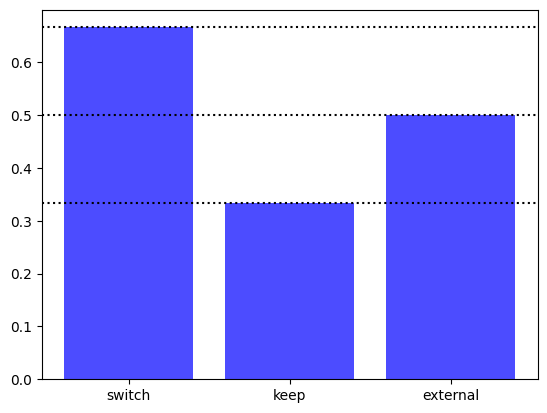

In [4]:
# Plotting the probabilities of winning for each strategy 
plt.bar([0,1,2], [probs[k] for k in probs.keys()], color='blue', alpha=0.7);
plt.xticks([0,1,2], probs.keys());

for y in [1/3,1/2,2/3]:
    plt.axhline(y, ls='dotted',c='black')

Now generalization with N door and p < N door opened by Monty

In [ ]:
def simulate_generalized_monty_hall(N, p, strategy, trials=100000):
    
    
    if p > N - 2:
        raise ValueError("The host can open a maximum of N - 2 doors.")       
    wins = 0 # Count the number of wins for the given strategy
    
    for _ in range(trials):
        winning_door = np.random.randint(0, N)
        choice = np.random.randint(0, N)
        
        if strategy == 'keep':
            if choice == winning_door:
                wins += 1
                
        elif strategy == 'switch':

            # Monty opens p doors that are neither the player's initial choice nor the winning door
            available_doors = [d for d in range(N) if d != choice and d != winning_door]
            
            # Monty randomly opens p doors among the available ones
            opened = np.random.choice(available_doors, p, replace=False) # replace=False ensures that the same door is not opened multiple times


            available_for_switch = [d for d in range(N) if d != choice and d not in opened]
            
        
            switched_choice = np.random.choice(available_for_switch)
            
            if switched_choice == winning_door:
                wins += 1
                
    return wins / trials


In [6]:
# Check the result for N = 3 and p = 1
N = 3
p = 1
print(f"Total Doors: {N}, Doors Opened: {p}")   
prob_keep = simulate_generalized_monty_hall(N, p, 'keep')
prob_switch = simulate_generalized_monty_hall(N, p, 'switch')
print(f"Empirical P(Keep):   {prob_keep:.4f} (Theoretical: {1/N:.4f})")
print(f"Empirical P(Switch): {prob_switch:.4f} (Theoretical: {((N-1)/N) * (1/(N-p-1)):.4f})")


Total Doors: 3, Doors Opened: 1
Empirical P(Keep):   0.3316 (Theoretical: 0.3333)
Empirical P(Switch): 0.6675 (Theoretical: 0.6667)


In [7]:
results = {
    10:   {'p_ratio': [], 'keep': [], 'switch': []},
    100:  {'p_ratio': [], 'keep': [], 'switch': []},
    1000: {'p_ratio': [], 'keep': [], 'switch': []}
}

# Loop through N and p values (added data points up to 8*N/10 for a smoother curve)
for N in [10, 100, 1000]:
    for p in [1, 2*int(N/10), 3*int(N/10), 4*int(N/10), 5*int(N/10), 6*int(N/10), 7*int(N/10), 8*int(N/10)]:
        # Ensure the host leaves at least one door closed (besides the player's choice)
        if p < N - 1:
            # Calculate probabilities using the simulation function
            prob_keep = simulate_generalized_monty_hall(N, p, 'keep')
            prob_switch = simulate_generalized_monty_hall(N, p, 'switch')
            
            print(f"N={N}, p={p} -> P(Keep): {prob_keep:.4f}, P(Switch): {prob_switch:.4f}")
            
            # Save the results for plotting. 
            # We use the ratio p/N on the X-axis to compare different N values on the same scale.
            results[N]['p_ratio'].append(p / N)
            results[N]['keep'].append(prob_keep)
            results[N]['switch'].append(prob_switch)


N=10, p=1 -> P(Keep): 0.1021, P(Switch): 0.1132
N=10, p=2 -> P(Keep): 0.0995, P(Switch): 0.1282
N=10, p=3 -> P(Keep): 0.0978, P(Switch): 0.1516
N=10, p=4 -> P(Keep): 0.0994, P(Switch): 0.1804
N=10, p=5 -> P(Keep): 0.0990, P(Switch): 0.2254
N=10, p=6 -> P(Keep): 0.1002, P(Switch): 0.2992
N=10, p=7 -> P(Keep): 0.0979, P(Switch): 0.4518
N=10, p=8 -> P(Keep): 0.1006, P(Switch): 0.8999
N=100, p=1 -> P(Keep): 0.0103, P(Switch): 0.0101
N=100, p=20 -> P(Keep): 0.0095, P(Switch): 0.0127
N=100, p=30 -> P(Keep): 0.0094, P(Switch): 0.0143
N=100, p=40 -> P(Keep): 0.0097, P(Switch): 0.0164
N=100, p=50 -> P(Keep): 0.0103, P(Switch): 0.0202
N=100, p=60 -> P(Keep): 0.0102, P(Switch): 0.0248
N=100, p=70 -> P(Keep): 0.0098, P(Switch): 0.0335
N=100, p=80 -> P(Keep): 0.0103, P(Switch): 0.0533
N=1000, p=1 -> P(Keep): 0.0010, P(Switch): 0.0009
N=1000, p=200 -> P(Keep): 0.0010, P(Switch): 0.0014
N=1000, p=300 -> P(Keep): 0.0012, P(Switch): 0.0015
N=1000, p=400 -> P(Keep): 0.0011, P(Switch): 0.0018
N=1000, p=5

<Figure size 1000x600 with 0 Axes>

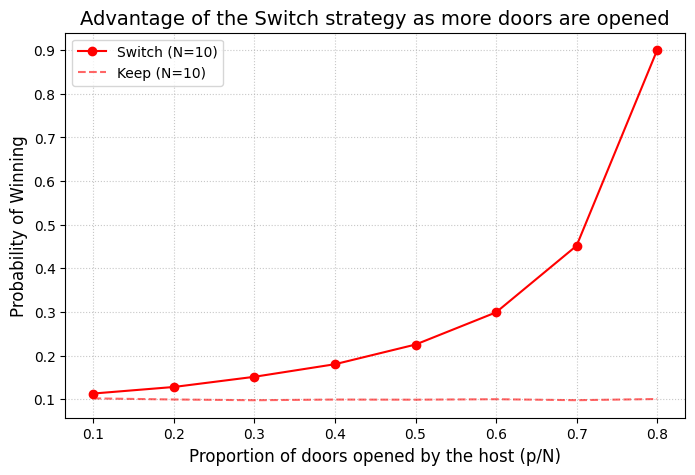

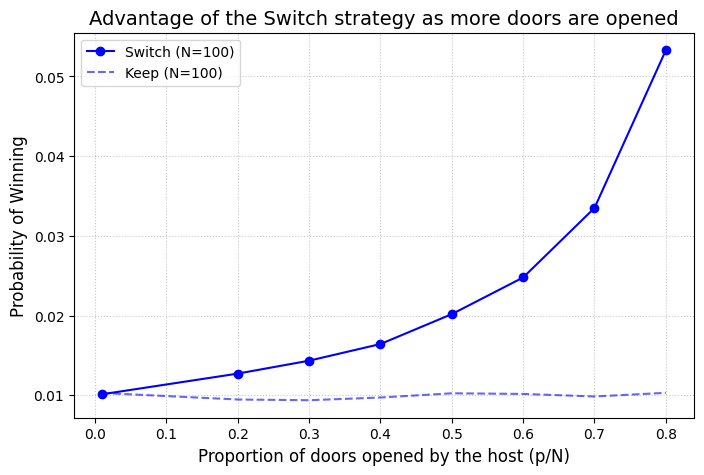

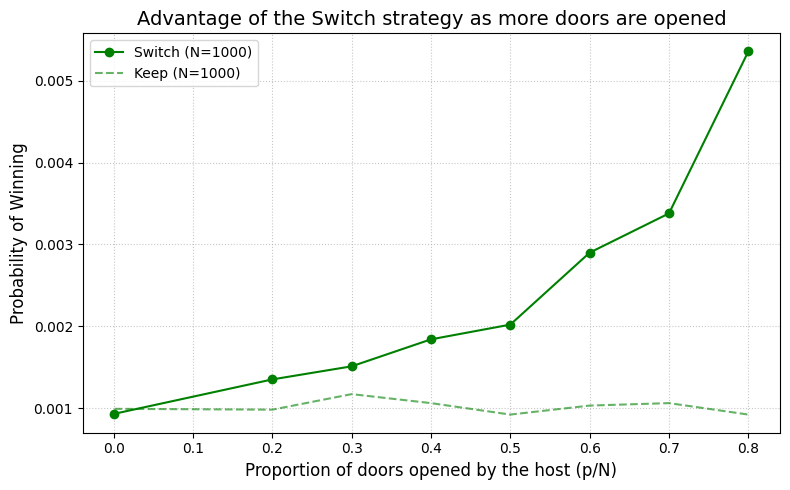

In [17]:
plt.figure(figsize=(10, 6))

colors = {10:'red', 100:'blue', 1000:'green'}

for N in [10, 100, 1000]:

    # line for the 'Switch' strategy
    plt.figure(figsize=(8, 5))
    plt.plot(results[N]['p_ratio'], results[N]['switch'], 
             marker='o', color=colors[N], label=f'Switch (N={N})')
    
    # line for the 'Keep' strategy
    plt.plot(results[N]['p_ratio'], results[N]['keep'], 
             linestyle='--', color=colors[N], alpha=0.6, label=f'Keep (N={N})')

    
    plt.xlabel('Proportion of doors opened by the host (p/N)', fontsize=12)
    plt.ylabel('Probability of Winning', fontsize=12)
    plt.title('Advantage of the Switch strategy as more doors are opened', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()